In [1]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import imageio
import pydicom
import SimpleITK as sitk


In [2]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_nib(file_path: str):
    nii_data = nib.load(file_path)

    image_data = nii_data.get_fdata()
    return image_data

def save_nib(file_path: str, volume):
    ct_image = sitk.GetImageFromArray(volume)
    sitk.WriteImage(ct_image, file_path)

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

In [27]:
a = load_npy('/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-0003/0003_NI001.npy')
a.shape

(128, 256, 256)

In [31]:
a.min()
a.sum()

-8203292194.0

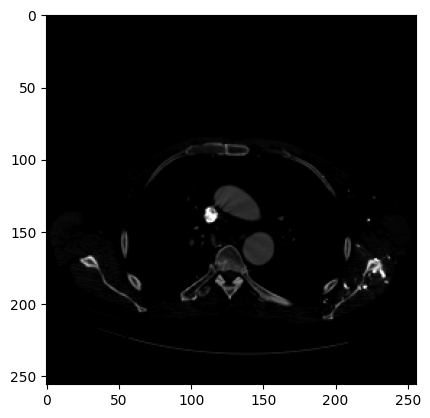

In [32]:
def brighten_ct(image, a_min=-1000, a_max=400, new_min=0.2, new_max=1.0):
    image = np.clip(image, a_min, a_max)  # Cắt giá trị ngoài khoảng HU
    image = (image - a_min) / (a_max - a_min)  # Chuẩn hóa về [0,1]
    image = image * (new_max - new_min) + new_min  # Đặt khoảng sáng hơn
    return np.clip(image, 0, 1)

b = brighten_ct(a)
plt.imshow(b[80], cmap="gray")

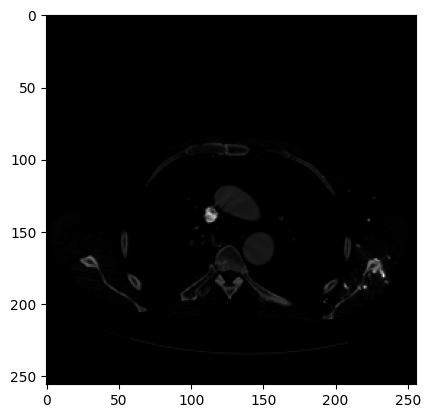

In [28]:
plt.imshow(a[80], cmap='gray')

(300, 300)
4062.0
-1024.0


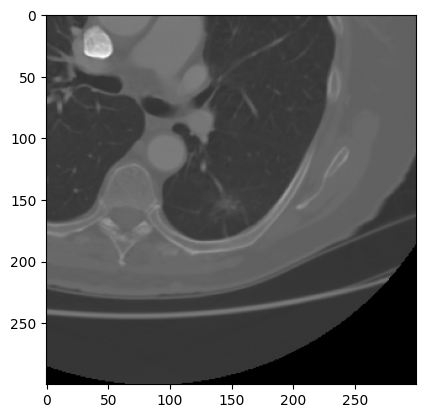

In [18]:
a = load_npy('/data/hpc/dqm/data/segment_data/Image/LIDC-IDRI-0001/0001_NI000_slice000.npy')
print(a.shape)
print(a.max())
print(a.min())
plt.imshow(a, cmap='gray')

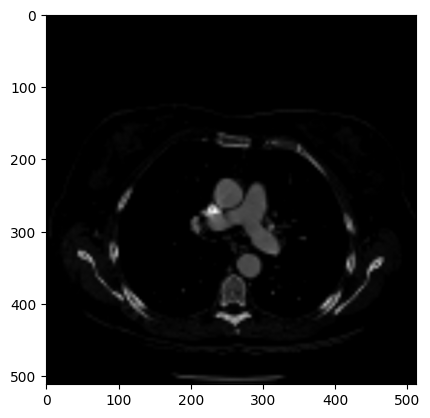

In [23]:
import numpy as np
from skimage.transform import resize

def resize_numpy(image: np.ndarray, target_size=(512, 512)):
    return resize(image, target_size, anti_aliasing=True)

# Ví dụ:
img = a[80, :, :]
resized_img = resize_numpy(img)
plt.imshow(resized_img, cmap='gray')

In [20]:
a= load_nib('/data/hpc/dqm/data/BTCV/imagesTr/img0002.nii.gz')
a.shape

(512, 512, 139)

In [3]:
def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

In [3]:
def numpy_to_gif(array, image_path="/data/hpc/dqm/3D-SegClass-Medical/images", case_name: str = "3", duration=100):
    if not os.path.exists(image_path):
        os.makedirs(image_path, exists_ok=True)
        
    save_path_x = f"{image_path}/{case_name}_x.gif"
    save_path_y = f"{image_path}/{case_name}_y.gif"
    save_path_z = f"{image_path}/{case_name}_z.gif"
    
    frames_x = []
    frames_y = []
    frames_z = []
    
    for i in range(array.shape[0]):
        img_x = Image.fromarray(scale_image(array[i, :, :])) 
        frames_x.append(img_x)
        img_y = Image.fromarray(scale_image(array[:, i, :])) 
        frames_y.append(img_y)
        img_z = Image.fromarray(scale_image(array[:, :, i])) 
        frames_z.append(img_z)

    frames_x[0].save(save_path_x, save_all=True, append_images=frames_x[1:], duration=duration, loop=0)
    frames_y[0].save(save_path_y, save_all=True, append_images=frames_y[1:], duration=duration, loop=0)
    frames_z[0].save(save_path_z, save_all=True, append_images=frames_z[1:], duration=duration, loop=0)
    


In [7]:
file_path = '/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-0033/0033_NI001.npy'

In [8]:
arr = load_npy(file_path)
numpy_to_gif(arr, case_name="case02_data_version2")

In [16]:
arr.max()

-1000.0

In [4]:
data = load_npy('/data/hpc/dqm/data/segment_data/Image/LIDC-IDRI-0031/0031_NI004_slice003.npy')
print(data.shape)
print(data.max())
print(data.min())


(279, 281)
3294.0
-1024.0


In [ ]:
numpy_to_gif(data, case_name="3")

In [8]:
mask_path = '/data/hpc/dqm/lidc-preprocessing/data/Image/LIDC-IDRI-0068/0068_NI001.npy'
data_mask = load_npy(mask_path)
# numpy_to_gif(data_mask, case_name="68_mask")
print(data_mask.shape)
print(data_mask.max())
print(data_mask.min())


(128, 128, 128)
400.0
-1000.0


# EDA Dicom

In [8]:
dicom_path = "/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-080.dcm"

dicom_data = load_dcom(dicom_path)
dicom_data

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.143451261327128179989900675595
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.14345126132712817

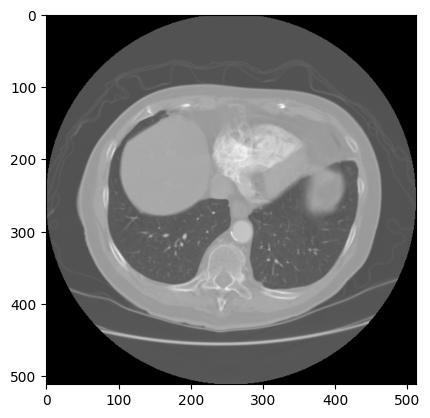

In [11]:
plt.imshow(dicom_data.pixel_array, cmap='gray')

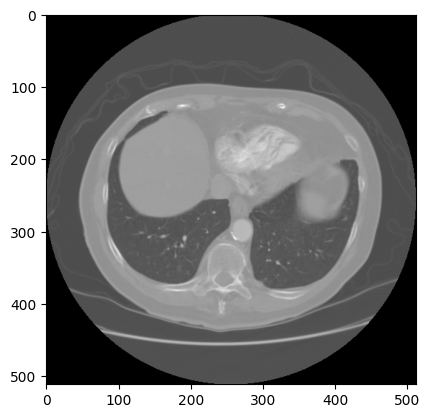

In [13]:
dicom_folder = "/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192"
dicom_files = sorted([f for f in os.listdir(dicom_folder) if f.endswith('.dcm')])

# Đọc một file DICOM
dicom_path = os.path.join(dicom_folder, dicom_files[80])
dicom_data = pydicom.dcmread(dicom_path)

plt.imshow(dicom_data.pixel_array, cmap='gray')

In [16]:
print("Patient ID:", dicom_data.PatientID)
print("Study Date:", dicom_data.StudyDate)
print("Modality:", dicom_data.Modality)
print("Slice Thickness:", dicom_data.SliceThickness)
print("Pixel Spacing:", dicom_data.PixelSpacing)

Patient ID: LIDC-IDRI-0001
Study Date: 20000101
Modality: CT
Slice Thickness: 2.500000
Pixel Spacing: [0.703125, 0.703125]


(133, 512, 512)


(-0.5, 511.5, 511.5, -0.5)

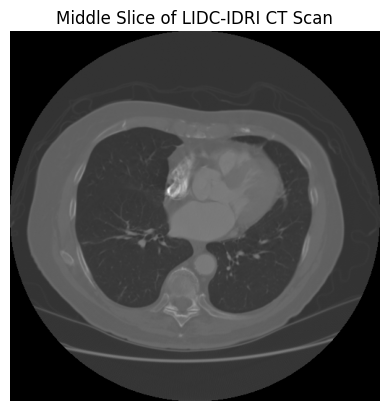

In [ ]:
def load_sitk(path):
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(path)
    reader.SetFileNames(dicom_names)
    image = reader.Execute()
    
    # numpy array
    img_array = sitk.GetArrayFromImage(image) # shape: (slices, height, width)
    return img_array

ct_scan = load_sitk(dicom_folder)

# Middle slice
plt.imshow(ct_scan[len(ct_scan)//2], cmap='gray')
plt.title("Middle Slice of LIDC-IDRI CT Scan")

In [ ]:
import pylidc as pl
import numpy as np
import matplotlib.pyplot as plt

# Lấy một scan bất kỳ từ database
scan = pl.query(pl.Scan).first()  

# Chuyển toàn bộ CT scan thành numpy array (slices, height, width)
volume = scan.to_volume()

print(f"Shape of 3D CT scan: {volume.shape}")  # (slices, height, width)


: 

In [8]:
path = '/data/hpc/dqm/data/brats-2021/TrainingData/jsons/brats2021_folds.json'

In [3]:
import json
import os

def datafold_read(
    data_dir: str, 
    datalist_json: str, 
    fold: int = 0, 
    key="training"
):
    with open(datalist_json) as f:
        json_data = json.load(f)

    json_data = json_data[key]

    for d in json_data:
        for k in d:
            if isinstance(d[k], list):
                d[k] = [os.path.join(data_dir, iv) for iv in d[k]]
            elif isinstance(d[k], str):
                d[k] = os.path.join(data_dir, d[k]) if len(d[k]) > 0 else d[k]

    tr = []
    val = []
    for d in json_data:
        if "fold" in d and d["fold"] == fold:
            val.append(d)
        else:
            tr.append(d)

    return tr, val

In [ ]:
# BRATS
tr, val = datafold_read('/data/hpc/dqm/data/brats-2021', '/data/hpc/dqm/data/brats-2021/TrainingData/jsons/brats21_folds.json')
tr

[{'fold': 1,
  'image': ['/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01266/BraTS2021_01266_flair.nii.gz',
   '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01266/BraTS2021_01266_t1ce.nii.gz',
   '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01266/BraTS2021_01266_t1.nii.gz',
   '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01266/BraTS2021_01266_t2.nii.gz'],
  'label': '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01266/BraTS2021_01266_seg.nii.gz'},
 {'fold': 1,
  'image': ['/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01619/BraTS2021_01619_flair.nii.gz',
   '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01619/BraTS2021_01619_t1ce.nii.gz',
   '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01619/BraTS2021_01619_t1.nii.gz',
   '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01619/BraTS2021_01619_t2.nii.gz'],
  'label': '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01619/BraTS2021_01619_seg.nii.gz'},
 {'fold': 1,
 

In [52]:
# BTCV
from monai.data import load_decathlon_datalist
train_files = load_decathlon_datalist('/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/dataset_0.json', True, "training")

train_files

[{'image': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/imagesTr/img0001.nii.gz',
  'label': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/labelsTr/label0001.nii.gz'},
 {'image': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/imagesTr/img0002.nii.gz',
  'label': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/labelsTr/label0002.nii.gz'},
 {'image': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/imagesTr/img0003.nii.gz',
  'label': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/labelsTr/label0003.nii.gz'},
 {'image': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/imagesTr/img0004.nii.gz',
  'label': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/labelsTr/label0004.nii.gz'},
 {'image': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/imagesTr/img0005.nii.gz',
  'label': '/data/hpc/dqm/3D-SegClass-Medical/preprocess_data/jsons/btcv/labelsTr/label0005.nii.g

In [19]:
# Brats sample
arr = load_nib('/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_00003/BraTS2021_00003_flair.nii.gz')
print(arr.shape)
print(arr.max())
print(arr.min())
print('-------------------------')
mask = load_nib('/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_00003/BraTS2021_00003_seg.nii.gz')
print(mask.shape)
print(mask.max())
print(mask.min())


(240, 240, 155)
3164.0
0.0
-------------------------
(240, 240, 155)
4.0
0.0


In [17]:
# BTCV sample
arr = load_nib('/data/hpc/dqm/data/RawData/Training/img/img0007.nii.gz')
print(arr.shape)
print(arr.max())
print(arr.min())
print('-------------------------')
mask = load_nib('/data/hpc/dqm/data/RawData/Training/label/label0007.nii.gz')
print(mask.shape)
print(mask.max())
print(mask.min())

(512, 512, 163)
2976.0
-1024.0
-------------------------
(512, 512, 163)
13.0
0.0


In [20]:
for i in range(68, 100):
    try:
        arr = load_npy(f'/data/hpc/dqm/lidc-preprocessing/data/Image_Segmentation/LIDC-IDRI-00{i}/00{i}_NI001.npy')
        if arr.max() != arr.min():
            print(arr.shape)
            print(arr.max())
            print(arr.min())
            print(i) # 69 78 79 84
        else:
            print(arr.max())
            print(arr.min())
            print(i)
    except Exception as e:
        continue


-1000.0
-1000.0
68
(128, 128, 128)
2.0022392868995667
-0.65671581402421
69
-1000.0
-1000.0
70


-1000.0
-1000.0
72
-1000.0
-1000.0
73
-1000.0
-1000.0
74
-1000.0
-1000.0
75
-1000.0
-1000.0
76
-1000.0
-1000.0
77
(87, 128, 128)
3.4769234359264374
-0.3969382718205452
78
(113, 128, 128)
2.788161888718605
-0.5317660048604012
79
-1000.0
-1000.0
80
-1000.0
-1000.0
81
-1000.0
-1000.0
82
-1000.0
-1000.0
83
(128, 128, 128)
4.447865515947342
-0.49070028960704803
84
-1000.0
-1000.0
85
-1000.0
-1000.0
86
-1000.0
-1000.0
87
-1000.0
-1000.0
88
-1000.0
-1000.0
89
-1000.0
-1000.0
90
-1000.0
-1000.0
91
-1000.0
-1000.0
92
-1000.0
-1000.0
93
-1000.0
-1000.0
94
-1000.0
-1000.0
95


KeyboardInterrupt: 

In [21]:
arr = load_npy(f'/data/hpc/dqm/lidc-preprocessing/data/Image_Segmentation/LIDC-IDRI-0069/0069_NI001.npy')

numpy_to_gif(arr, case_name="image_segmentation_15")

In [30]:
numpy_to_gif(arr, case_name='abc')